# Actividad 11 – Filtrar contornos por área

**Objetivo**: eliminar ruido filtrando contornos.

En esta actividad vamos a:
1. Cargar una imagen
2. Detectar contornos
3. Calcular área de cada contorno
4. Dibujar solo los que tengan área mayor a 500
5. Mostrar el resultado

## 1. Importar librerías necesarias

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar imagen

Cambia la ruta por la ubicación de tu imagen.

✓ Imagen cargada correctamente


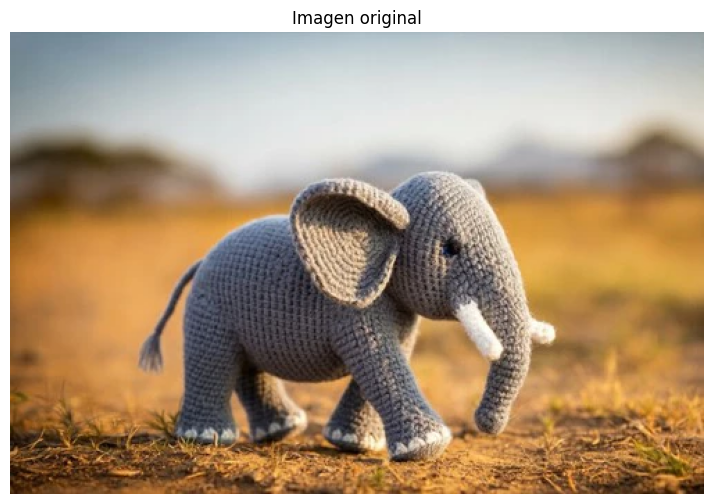

In [2]:
# Cargar la imagen
imagen = cv2.imread('imagen.webp')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    
    # Mostrar la imagen original
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title('Imagen original')
    plt.show()

## 3. Preprocesar imagen para detección de contornos

Convertimos a escala de grises y aplicamos umbralización binaria.

✓ Imagen preprocesada
  Escala de grises: (333, 500)
  Imagen binaria:   (333, 500)


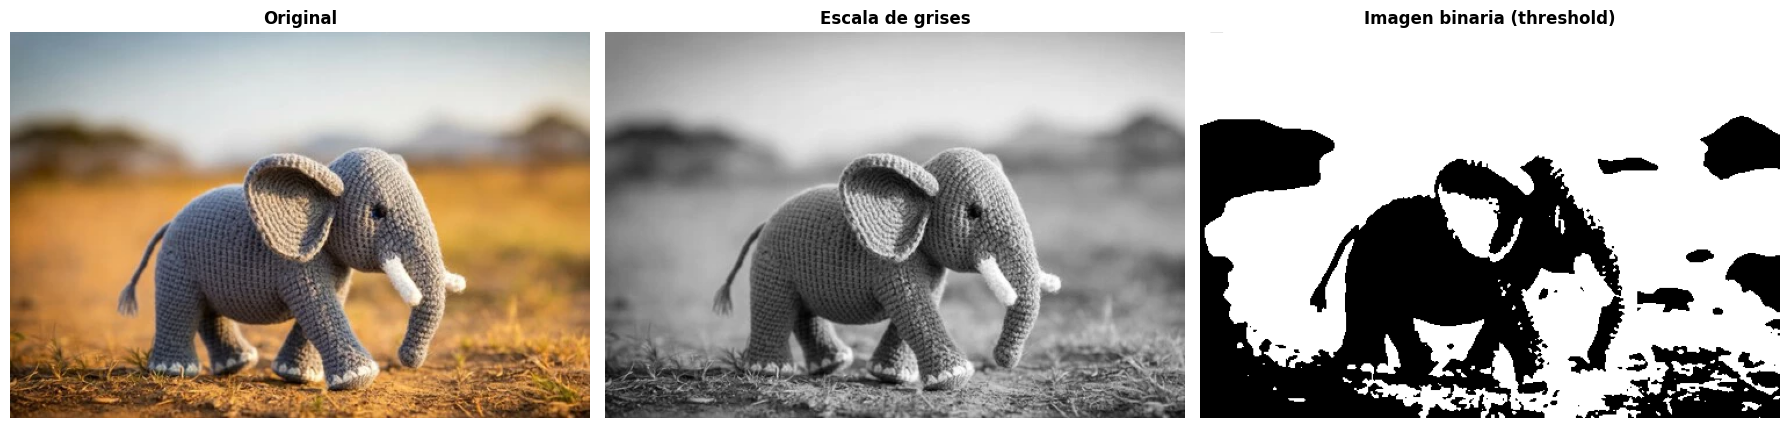

In [3]:
# Convertir a escala de grises
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

# Aplicar desenfoque para reducir ruido
imagen_blur = cv2.GaussianBlur(imagen_gris, (5, 5), 0)

# Aplicar umbralización binaria
# Puedes usar threshold simple o adaptativo según la imagen
_, imagen_binaria = cv2.threshold(imagen_blur, 127, 255, cv2.THRESH_BINARY)

# Alternativamente, usa threshold adaptativo para imágenes con iluminación variable:
# imagen_binaria = cv2.adaptiveThreshold(imagen_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
#                                         cv2.THRESH_BINARY, 11, 2)

print("✓ Imagen preprocesada")
print(f"  Escala de grises: {imagen_gris.shape}")
print(f"  Imagen binaria:   {imagen_binaria.shape}")

# Visualizar el preprocesamiento
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(imagen_gris, cmap='gray')
axes[1].set_title('Escala de grises', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(imagen_binaria, cmap='gray')
axes[2].set_title('Imagen binaria (threshold)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. Detectar contornos

Usamos `cv2.findContours()` para detectar todos los contornos en la imagen.

✓ Contornos detectados: 69


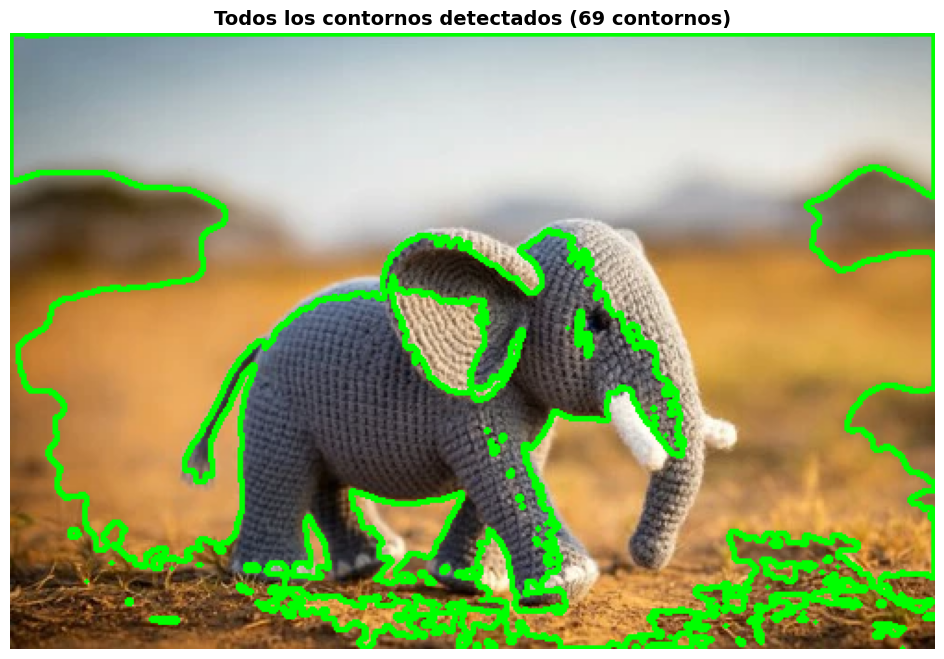

In [4]:
# Detectar contornos
# RETR_EXTERNAL: solo contornos externos
# RETR_TREE: todos los contornos con jerarquía
# CHAIN_APPROX_SIMPLE: comprime segmentos horizontales, verticales y diagonales
contornos, jerarquia = cv2.findContours(imagen_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"✓ Contornos detectados: {len(contornos)}")

# Dibujar TODOS los contornos detectados (para comparación posterior)
imagen_todos_contornos = imagen_rgb.copy()
cv2.drawContours(imagen_todos_contornos, contornos, -1, (0, 255, 0), 2)

plt.figure(figsize=(12, 8))
plt.imshow(imagen_todos_contornos)
plt.title(f'Todos los contornos detectados ({len(contornos)} contornos)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

## 5. Calcular área y filtrar contornos

Calculamos el área de cada contorno con `cv2.contourArea()` y filtramos los que superen el umbral.

In [5]:
# Definir umbral de área mínima
area_minima = 500

# Filtrar contornos por área
contornos_filtrados = []
areas_todos = []
areas_filtradas = []

for contorno in contornos:
    area = cv2.contourArea(contorno)
    areas_todos.append(area)
    
    if area > area_minima:
        contornos_filtrados.append(contorno)
        areas_filtradas.append(area)

print("="*60)
print("ANÁLISIS DE CONTORNOS")
print("="*60)
print(f"Total contornos detectados:  {len(contornos)}")
print(f"Contornos filtrados (área > {area_minima}): {len(contornos_filtrados)}")
print(f"Contornos eliminados (ruido): {len(contornos) - len(contornos_filtrados)}")
print("="*60)

if len(areas_filtradas) > 0:
    print(f"\nEstadísticas de áreas filtradas:")
    print(f"  Área mínima:   {min(areas_filtradas):.2f} px²")
    print(f"  Área máxima:   {max(areas_filtradas):.2f} px²")
    print(f"  Área promedio: {np.mean(areas_filtradas):.2f} px²")
    print("="*60)

ANÁLISIS DE CONTORNOS
Total contornos detectados:  69
Contornos filtrados (área > 500): 4
Contornos eliminados (ruido): 65

Estadísticas de áreas filtradas:
  Área mínima:   1430.00 px²
  Área máxima:   102158.00 px²
  Área promedio: 26765.50 px²


## 6. Mostrar resultado con contornos filtrados

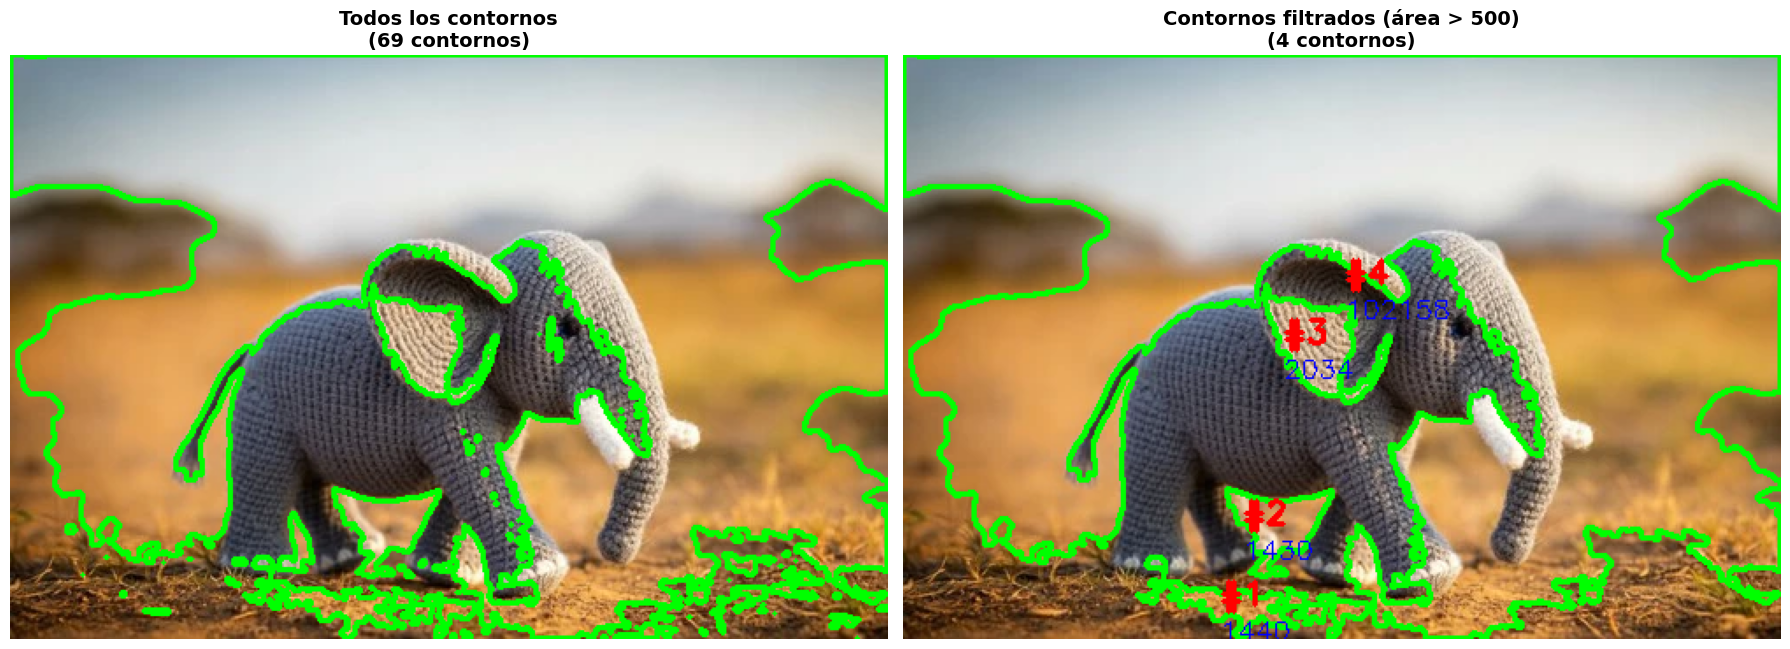


✓ Filtrado completado
Se han eliminado 65 contornos pequeños (ruido)


In [6]:
# Dibujar solo los contornos filtrados
imagen_filtrada = imagen_rgb.copy()
cv2.drawContours(imagen_filtrada, contornos_filtrados, -1, (0, 255, 0), 2)

# Opcional: numerar los contornos filtrados y mostrar su área
for i, (contorno, area) in enumerate(zip(contornos_filtrados, areas_filtradas)):
    # Calcular el centroide del contorno
    M = cv2.moments(contorno)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        
        # Dibujar número y área
        cv2.putText(imagen_filtrada, f"#{i+1}", (cX - 20, cY), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        cv2.putText(imagen_filtrada, f"{area:.0f}", (cX - 20, cY + 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

# Mostrar comparación
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Todos los contornos
axes[0].imshow(imagen_todos_contornos)
axes[0].set_title(f'Todos los contornos\n({len(contornos)} contornos)', 
                  fontsize=14, fontweight='bold')
axes[0].axis('off')

# Contornos filtrados
axes[1].imshow(imagen_filtrada)
axes[1].set_title(f'Contornos filtrados (área > {area_minima})\n({len(contornos_filtrados)} contornos)', 
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Filtrado completado")
print(f"Se han eliminado {len(contornos) - len(contornos_filtrados)} contornos pequeños (ruido)")